# 03 - Neural Networks

## Imports

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Make sure we get outputs from a probabilitistic model each time (for reproducibility) 
np.random.seed(1515)

## Why do we even need Neural Networks?

You might be wondering why we need to cover a fairly advanced ML topic to perform our robotics tasks. Neural Networks, or Neural Nets or NNs for short, are very useful because they help us model complex relationships between inputs and outputs. 

For instance, our previous ML example of AP Calculus AB used some basic regression techniques with lines to map a relationship - but what if we need more nonlinearity? What if we need a composition of functions to map a relationship without overfitting? 

This is where NNs come in, and they will be *very* powerful in helping us form the foundation of understanding for image classification by extension object detection. 

## Basics of Neural Networks

### Building Blocks

Let's look at a single neuron: 

![](./ref_imgs/single_neuron.png)

I'm sure this is a lot to look at - but let's dive in to better understand these components on a higher level

#### Neurons

Neurons are the smallest unit of a neural network. Looking at that picture above, a neuron consists of inputs $x_i, i\in[1, n]$, weights $w_i, i\in[1, n]$ a bias term $b$, and a function $f$. These components on their own are relatively simple - the formula above $f(b + \sum_{i=1}^{n}x_iw_i)$ can be thought of as simply applying a function to weighted inputs. 

Overall, nothing special is happening here - it is a simple function transformation. However, when we start to add more and more neurons, we can see that we can map some pretty unique relationships.

#### Layers

Let's look at a diagram of a full neural network below:

![](./ref_imgs/nn_diagram.png)

You can think of NNs as a **composition of layers**, where each layer represents a function. In fact, the term **Deep Learning** (DL) refers to tools that deploy multiple layers! 

As you can see, we have multiple neurons that are present in a given neural network. 

Where NNs are special is that while the layers themselves tend to be linear functions, in between each layer, we apply **activation** functions (nonlinear functions) that help to capture nonlinear relationships, something that is crucial in understanding images. 

We can break down the layers of NNs into 3 different categories: 

1. Input Layers: receives features (numbers) 
2. Hidden Layers: applies intermediate transformations to these inputs
3. Output Layers: produces final predictions

It is by combining these various layers that we are able to map some complex relationships.

## NN example: Classifying Digits

To motivate why neural networks are useful (and why more basic classifiers fall short), let's look at a very famous problem machine learning: digit classification. We use scikit-learn's built in digit classification dataset for the sake of skipping over some of the data processing steps. 

### Our Data

X shape: (1797, 64)
images shape: (1797, 8, 8)
classes: [0 1 2 3 4 5 6 7 8 9]


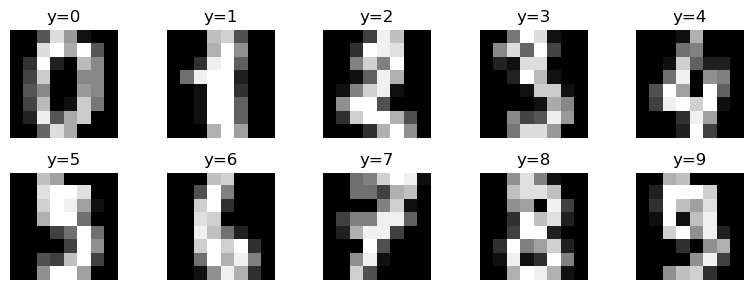

In [30]:
# read in our data and visualize some examples

digits = load_digits()
X = digits.data          # flattened 8x8 -> 64 features
y = digits.target
images = digits.images   # original 8x8 images

print("X shape:", X.shape)
print("images shape:", images.shape)
print("classes:", np.unique(y))

# Visualize a few examples
fig = plt.figure(figsize=(8, 3))
for i in range(10):
    ax = fig.add_subplot(2, 5, i+1)
    ax.imshow(images[i], cmap="gray")
    ax.set_title(f"y={y[i]}")
    ax.axis("off")
plt.tight_layout()
plt.show()